In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import zarr
from pathlib import Path
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.patches import Circle

POSSIBLE_ROOTS = [
    Path('/Volumes/data-1/Sasaki/MTsingleBeads'),
    Path('/Volumes/data-1/sasaki/MTsingleBeads'),
    Path('/Volumes/data/Sasaki/MTsingleBeads'),
    Path('/Volumes/data/sasaki/MTsingleBeads'),
    Path('/Volumes/data/Sasaki/MTSingleBeads'),
]



input_dir = POSSIBLE_ROOTS[2]/'beads5um/20260715/beads5um003'

output_dir = POSSIBLE_ROOTS[2] / "figure/exp_snap"

MTs = zarr.open(input_dir / 'GFP.zarr', mode='r')
beads = zarr.open(input_dir / 'beads.zarr', mode='r')

df = pd.read_csv(input_dir /'beads_tracks.csv')


bead_diameter_um = 1.18  # ビーズの直径 [μm]
pixel_size_um = 0.11  # 空間解像度 [μm/px]
bead_radius_px = (bead_diameter_um / pixel_size_um / 2)

In [113]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

gfp_base = mcolors.to_rgb("#00A960")  # (0.0, 0.663, 0.376)

cud_gfp_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_gfp",
    [
        (0.0, (0.0, 0.0, 0.0, 1.0)),              # 輝度0: 完全透明な黒
        (0.7, (gfp_base[0], gfp_base[1], gfp_base[2], 1.0)), # 輝度70%: 純粋なCUD緑（半透明）
        (1.0, (0.6, 1.0, 0.75, 1.0))              # 輝度100%: 芯が光るエメラルドホワイト（不透明）
    ]
)

beads_base = mcolors.to_rgb("#E4007F")  # (0.894, 0.0, 0.498)

cud_magenta_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_magenta",
    [
        (0.0, (0.0, 0.0, 0.0, 0.0)),                  # 輝度0: 完全透明な黒
        (0.7, (beads_base[0], beads_base[1], beads_base[2], 0.7)), # 輝度70%: 純粋なCUDマゼンタ（半透明）
        (1.0, (1.0, 0.65, 0.85, 1.0))                  # 輝度100%: 芯が光るパステルマゼンタホワイト（不透明）
    ]
)
MTs_max_factor = 0.15
beads_max_factor = 0.7

# カラーマップ (plasma) とフレームの正規化範囲を設定
cmap = plt.get_cmap("plasma")
norm = plt.Normalize(vmin=df["frame"].min(), vmax=df["frame"].max())

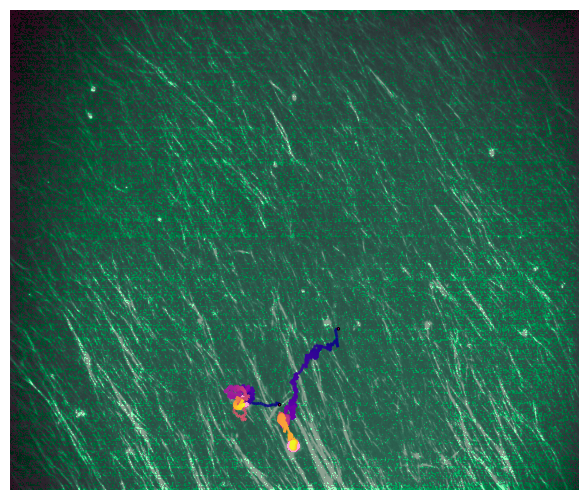

In [114]:
# 図を2つ並べて表示する場合
fig, ax = plt.subplots()
# 最初のプロット：MTs
ax.imshow(MTs[-1], cmap=cud_gfp_cmap, vmin=MTs[-1].min(), vmax = MTs[-1].max()*MTs_max_factor)

# 2番目のプロット：beads（マスク付き）
ax.imshow(beads[-1], cmap=cud_magenta_cmap, interpolation="nearest", vmin=beads[-1].min(), vmax = beads[-1].max()*beads_max_factor)

# 各粒子（particle）ごとに軌跡を線分に分解して描画
for particle_id, group in df.groupby("particle"):
    group = group.sort_values("frame")

    # (N, 2) の座標列を (N-1, 2, 2) の線分配列に変換
    points = np.array([group["x"], group["y"]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 各線分の始点フレーム番号を色として割り当て
    frames = group["frame"].values[:-1]

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2, alpha=0.9)
    lc.set_array(frames)
    ax.add_collection(lc)

    # 始点マーカー（実寸大の Circle パッチ）
    start_x = group["x"].iloc[0]
    start_y = group["y"].iloc[0]
    start_color = cmap(norm(group["frame"].iloc[0]))

    circle = Circle(
      xy=(start_x, start_y),
      radius=bead_radius_px,
      facecolor="#E4007F",
      edgecolor="black",
      linewidth=0.8,
      zorder=5,
    )
    ax.add_patch(circle)

ax.axis('off')
ax.set_position([0, 0, 1, 1]) # AxesをFigure全体に限界まで広げる
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

fontprops = fm.FontProperties(size=24)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/0.11,
                           label='',
                           loc=3,
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
#ax.add_artist(size_bar)


In [115]:
fig.savefig(output_dir / "beads5um003.pdf", bbox_inches="tight")

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from tifffile import TiffFile
from tifffile import imread
from pathlib import Path
import os
import zarr

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')
root = Path('/Volumes/data/Sasaki/MTsingleBeads')

folder = root / "beads06um" / "20260716" / "beads06um001"
flow = folder / "GFP_flows.h5"
MTs = zarr.open(folder / 'GFP.zarr', mode='r')


import matplotlib.colors as mcolors

gfp_base = mcolors.to_rgb("#00A960")  # (0.0, 0.663, 0.376)

cud_gfp_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_gfp",
    [
        (0.0, (0.0, 0.0, 0.0, 1.0)),              # 輝度0: 完全透明な黒
        (0.7, (gfp_base[0], gfp_base[1], gfp_base[2], 1.0)), # 輝度70%: 純粋なCUD緑（半透明）
        (1.0, (0.6, 1.0, 0.75, 1.0))              # 輝度100%: 芯が光るエメラルドホワイト（不透明）
    ]
)

# GFP_flows.h5からフレーム0の流れ場を取得
with h5py.File(flow, 'r') as f:
    # f['flows'] のshapeは (T, 2, H, W) 
    flow_data = f['flows'][-1].astype(np.float32)


# 流れ場の大きさ(magnitude)を計算
# チャネル0と1がそれぞれ y(v), x(u) 方向のフローと仮定
v = flow_data[1]
u = flow_data[0]
magnitude = np.sqrt(u**2 + v**2)

# ベクトルを描画する場合はダウンサンプリングする
step = 64
y_grid, x_grid = np.mgrid[0:magnitude.shape[0]:step, 0:magnitude.shape[1]:step]
u_down = u[::step, ::step]
v_down = v[::step, ::step]

# ダウンサンプリング後の大きさを計算
mag_down = np.sqrt(u_down**2 + v_down**2)

# --- 異常値（外れ値）の除去 ---
# 方法1: パーセンタイルで上位の外れ値を自動カット（例: 上位2%を除去）
threshold = np.percentile(mag_down, 98)

# 方法2: 明確な上限値（ピクセル/フレーム）が分かっている場合の固定値指定
# threshold = 10.0

# 閾値を超えるベクトルを NaN に置き換えて非表示にする
mask_invalid = mag_down > threshold
u_down[mask_invalid] = np.nan
v_down[mask_invalid] = np.nan


MTs_max_factor= 0.3



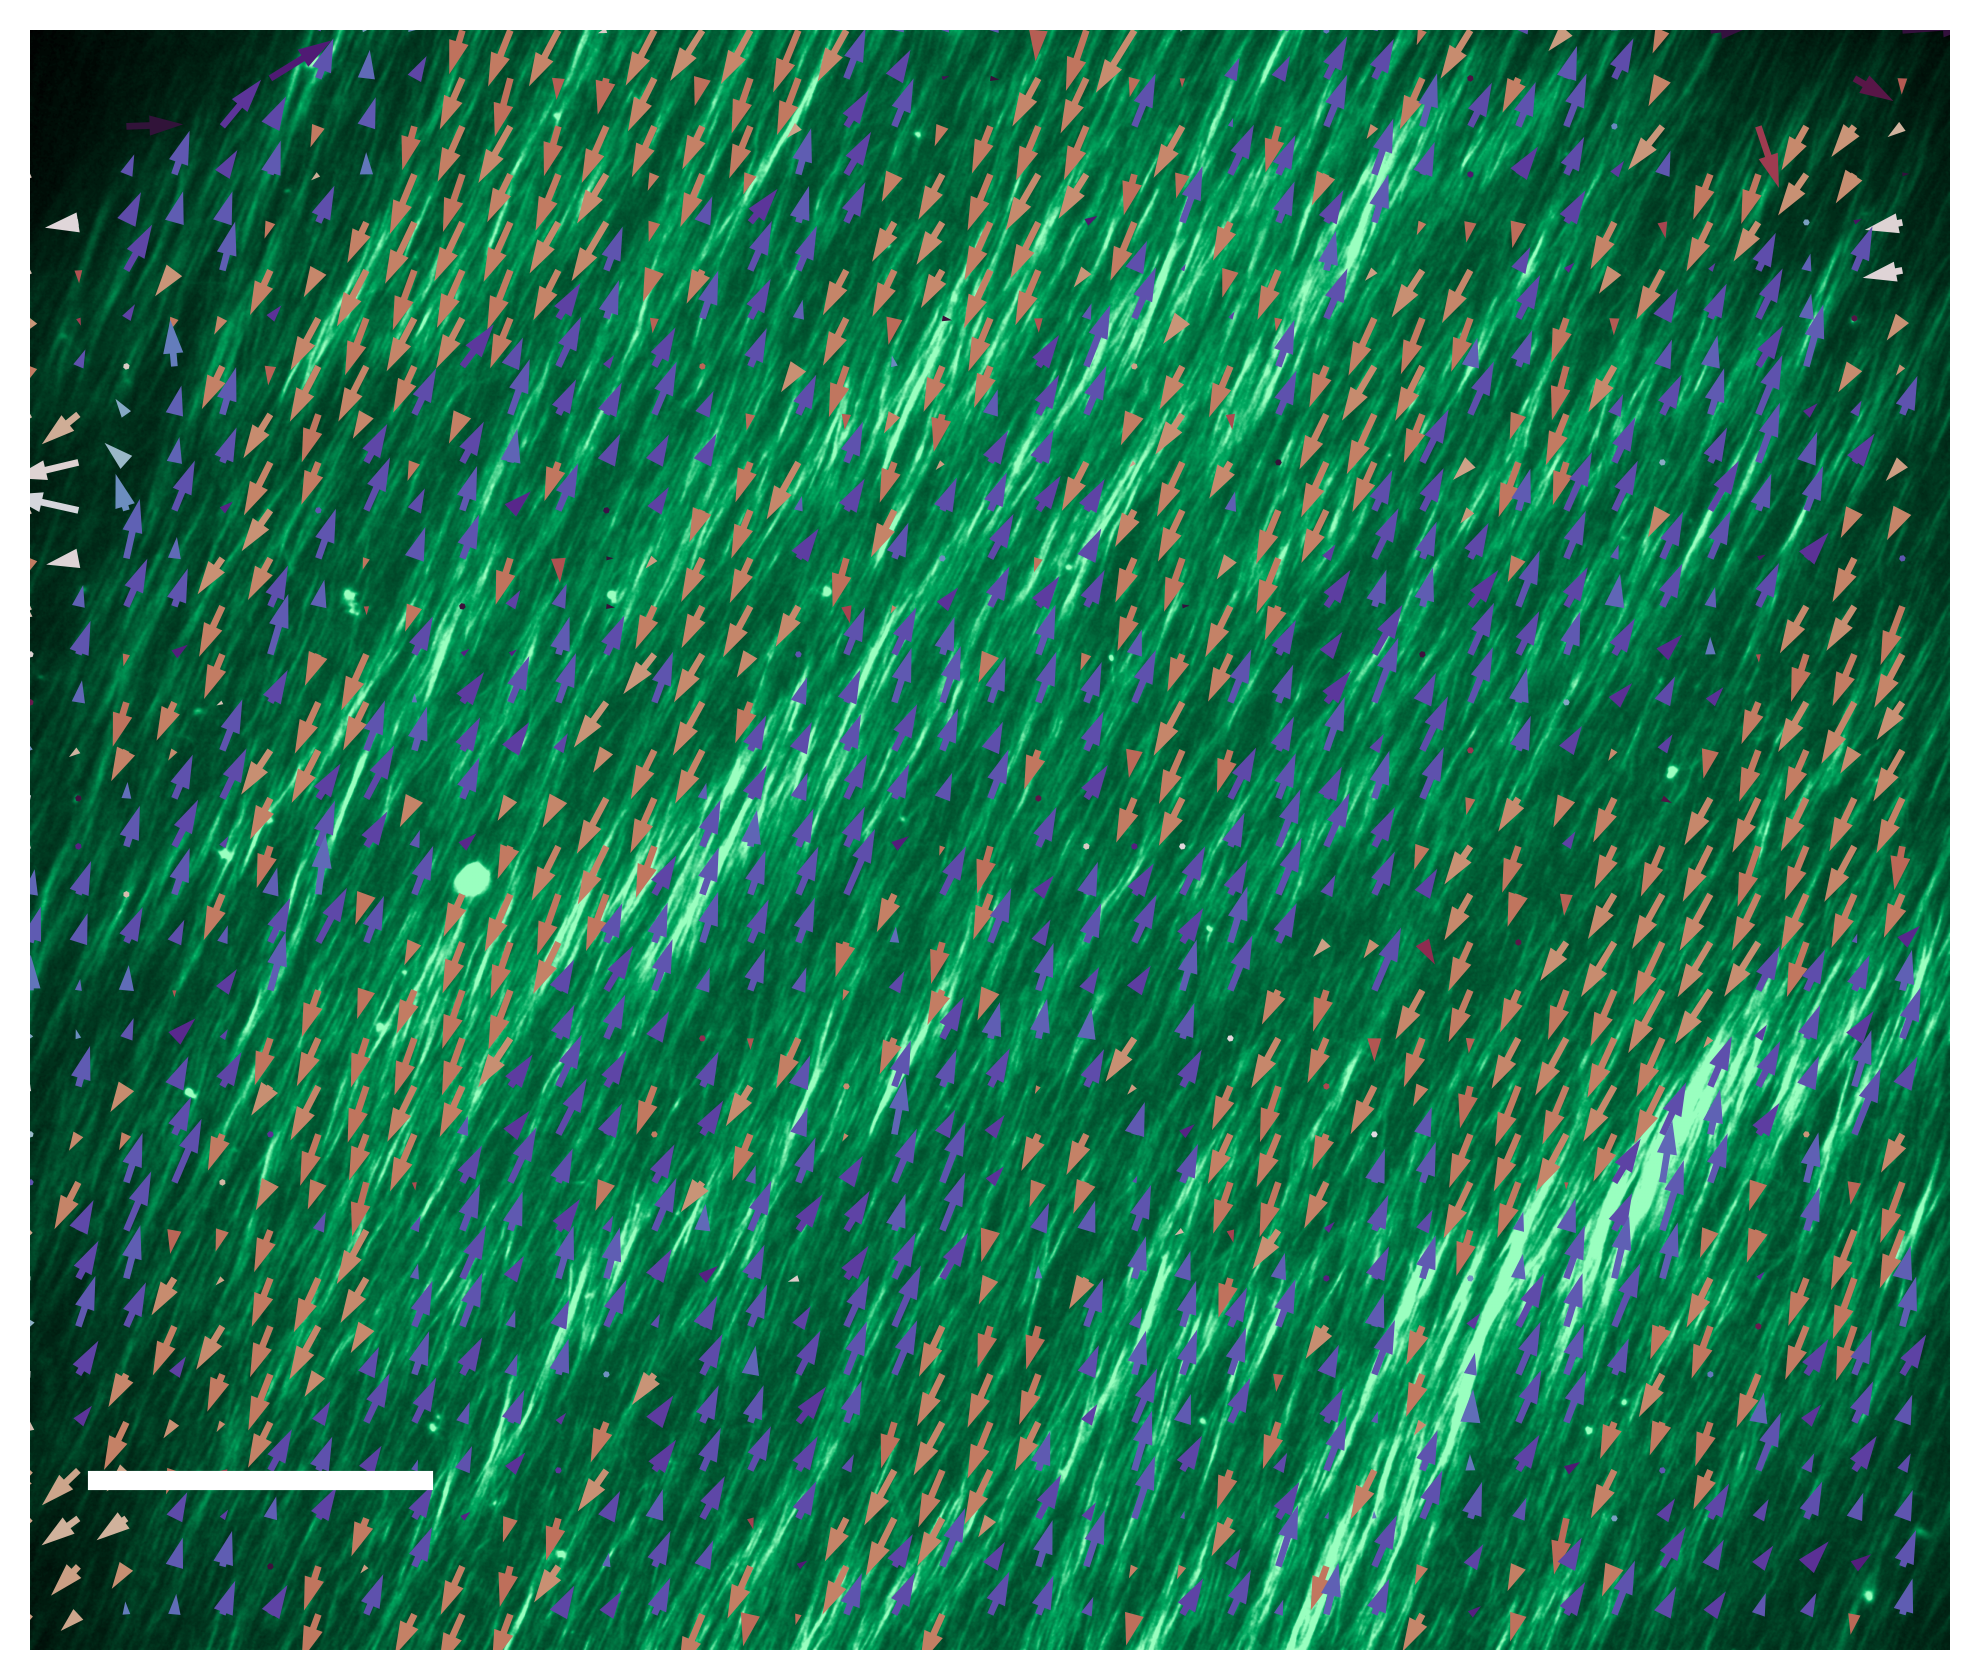

In [14]:
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
# 角度（ラジアン: -pi 〜 pi）の計算
angles = np.arctan2(v_down, u_down)

fig, ax = plt.subplots()


im = ax.imshow(MTs[-1], cmap=cud_gfp_cmap, origin='upper',  vmin=MTs[-1].min(), vmax = MTs[-1].max()*MTs_max_factor)

# 描画する矢印のスケール（値が小さいほど矢印が長く描画される）
# scale_units='xy' とすることで、流れ場とビーズの変位の長さを比較可能にする
shared_scale = 0.15

# 流れ場の向きを矢印でプロット（Quiver、白色）
#ax.quiver(x_grid, y_grid, u_down, v_down, color=(255/255, 0, 147/255), linewidth=1, alpha = 0.8, headlength = 2, headaxislength=2.5, angles='xy', scale_units='xy', scale=shared_scale, label='Optical Flow')

norm_angle = mcolors.Normalize(vmin=-np.pi, vmax=np.pi)
q = ax.quiver(
    x_grid, y_grid, u_down, v_down, angles,
    cmap='twilight', norm=norm_angle,
    angles='xy', scale_units='xy', scale=shared_scale,
    width=0.0035,        # 軸を太めにする
    headwidth=3,       # 矢頭の幅を広げる
    headlength=5,      # 矢頭の長さを確保
    headaxislength=5.0,
    linewidth=0.4,
    alpha = 1
)
ax.set_position([0, 0, 1, 1]) # AxesをFigure全体に限界まで広げる
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)
ax.axis('off')

fontprops = fm.FontProperties(size=24)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/0.11,
                           label='',
                           loc=3,
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
ax.add_artist(size_bar)


In [15]:
fig.savefig(root/"figure/exp_snap/beads06um001_flow.png")
fig.savefig(root/"figure/exp_snap/beads06um001_flow.pdf")

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# 設定
# --------------------------------------------------
output_name = "twilight_color_wheel_clean"
dpi = 300

# 角度グリッド（0 〜 2pi で完全な円周を作成）
theta = np.linspace(0, 2 * np.pi, 500)

# 半径グリッドの設定:
# ・ドーナツ型（リング）にする場合: 内径 0.65, 外径 1.0
r = np.linspace(0, 1.0, 50)
# ・中実の円盤（中心まで埋める）にする場合:
# r = np.linspace(0.0, 1.0, 50)

T, R = np.meshgrid(theta, r)

# twilight 用の角度値（-pi 〜 pi）へのマッピング
alpha = np.where(theta <= np.pi, theta, theta - 2 * np.pi)
Alpha, _ = np.meshgrid(alpha, r)

# --------------------------------------------------
# プロット作成
# --------------------------------------------------
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='polar')

# 画像座標系（右が0、下が正）に合わせる
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)

# グリッドの無効化と描画
ax.grid(False)
norm_angle = mcolors.Normalize(vmin=-np.pi, vmax=np.pi)
ax.pcolormesh(T, R, Alpha, cmap='twilight', norm=norm_angle, shading='auto')

# 軸・目盛り・枠線をすべて非表示にする
ax.axis('off')

# 背景を完全透明化
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# --------------------------------------------------
# 保存
# --------------------------------------------------
plt.tight_layout()
plt.savefig(root/"figure/exp_snap/wheel_flow.png", dpi=dpi, transparent=True, bbox_inches='tight', pad_inches=0)
#
plt.close()

In [27]:
plt.savefig(root/"figure/exp_snap/wheel_flow.svg", bbox_inches='tight', pad_inches=0)

<Figure size 2400x1800 with 0 Axes>